
# 小売店 売上分析＆Excelレポート自動生成

## このノートブックについて

小売店（名古屋市内で複数部門を展開する想定）の売上データをもとに、
**「分析して終わり」ではなく「日々の定例レポート作成を自動化する」ところまで**を
一貫して行うポートフォリオです。

- 前半：`pandas` / `matplotlib` によるデータ分析（トレンド・部門比較・商品ランキング）
- 後半：`openpyxl` を使い、分析結果をExcelファイルとして自動出力（グラフ付き）

前職（生産管理・品質管理）で、日次・月次の実績レポートを手作業で作成していた経験から、
「この集計作業をPythonで自動化したらどれくらい楽になるか」を実際に手を動かして検証しました。

> **データについて**：`data/generate_data.py` で生成した疑似データです（乱数シード固定・再現可能）。


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from openpyxl import Workbook
from openpyxl.chart import BarChart, LineChart, Reference
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils.dataframe import dataframe_to_rows

plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)


## 1. データ読み込み・前処理

In [2]:

dept = pd.read_csv("../data/department_sales.csv", parse_dates=["date"])
product = pd.read_csv("../data/product_sales.csv", parse_dates=["date"])

# 欠損値確認
print("department_sales 欠損:", dept.isna().sum().sum())
print("product_sales    欠損:", product.isna().sum().sum())

# 月情報の付与
dept["month"] = dept["date"].dt.to_period("M").astype(str)
product["month"] = product["date"].dt.to_period("M").astype(str)

dept.head()


department_sales 欠損: 0
product_sales    欠損: 0


,date,department,amount,month
0,2026-01-01,食品,96051,2026-01
1,2026-01-01,日用品,44865,2026-01
2,2026-01-01,衣料品,48432,2026-01
3,2026-01-01,雑貨,28330,2026-01
4,2026-01-02,食品,92548,2026-01


## 2. 部門別売上の分析

In [3]:

dept_monthly = dept.pivot_table(index="month", columns="department", values="amount", aggfunc="sum")
dept_monthly = dept_monthly[["食品", "日用品", "衣料品", "雑貨"]]  # 表示順を固定
dept_monthly_man = (dept_monthly / 10000).round(1)  # 万円単位
dept_monthly_man


department,食品,日用品,衣料品,雑貨
month,,,,
2026-01,311.2,143.6,163.9,100.4
2026-02,291.1,130.1,152.4,93.0
2026-03,320.6,145.8,162.7,101.6
2026-04,294.8,133.6,141.0,89.3
2026-05,283.1,136.5,127.7,84.8
2026-06,243.6,126.7,98.0,73.6


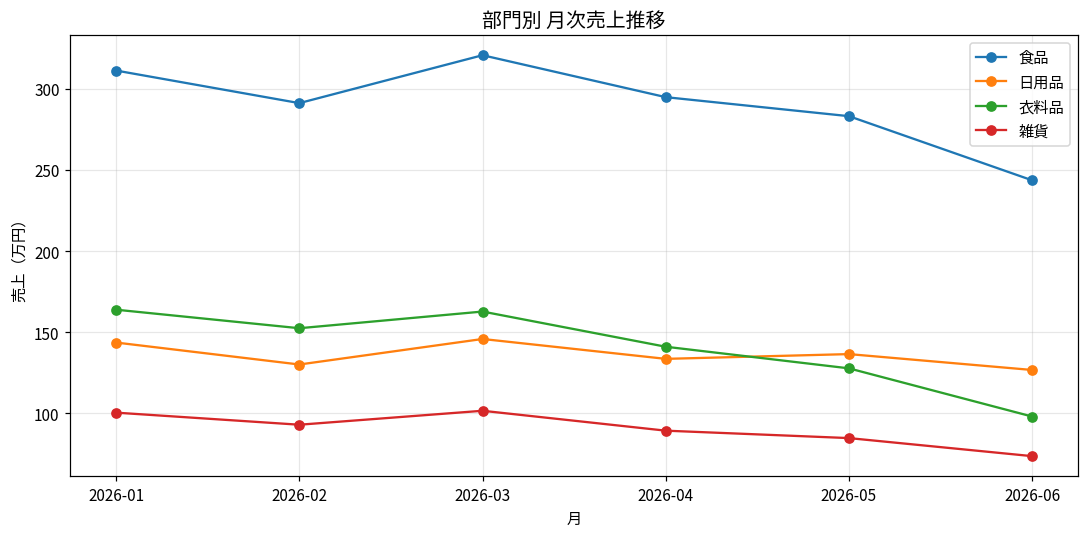

In [4]:

fig, ax = plt.subplots(figsize=(10, 5))
for col in dept_monthly.columns:
    ax.plot(dept_monthly.index, dept_monthly[col] / 10000, marker="o", label=col)

ax.set_title("部門別 月次売上推移", fontsize=13)
ax.set_ylabel("売上（万円）")
ax.set_xlabel("月")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../images/dept_monthly_trend.png")
plt.show()



**読み取れること**：衣料品は季節変動が大きく、冬（1月・12月）に売上が伸びる一方で夏場は落ち込む
傾向がはっきり出ています。食品は安定して最大の売上規模を保っており、店舗全体の収益の土台に
なっていることが分かります。


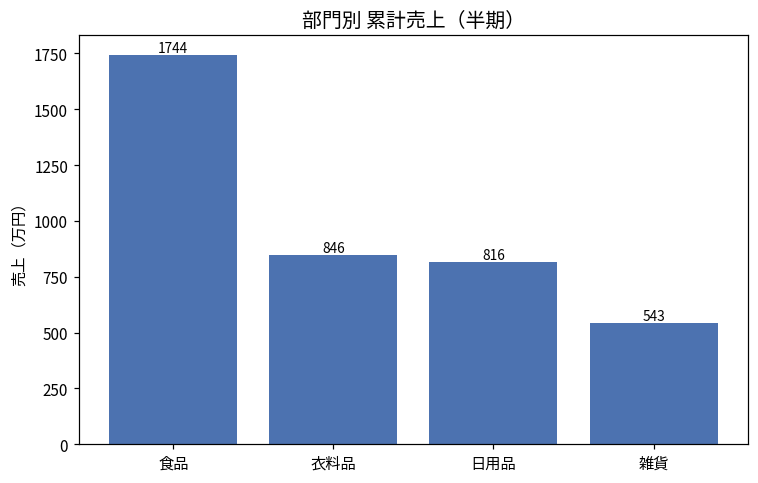

In [5]:

dept_total = dept.groupby("department")["amount"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(dept_total.index, dept_total.values / 10000, color="#4C72B0")
ax.set_title("部門別 累計売上（半期）", fontsize=13)
ax.set_ylabel("売上（万円）")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{b.get_height():.0f}",
            ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig("../images/dept_total.png")
plt.show()


## 3. 商品別売上ランキング

In [6]:

product_rank = (
    product.groupby(["product", "department"])["amount"]
    .sum()
    .reset_index()
    .sort_values("amount", ascending=False)
)
product_rank["amount_man"] = (product_rank["amount"] / 10000).round(1)
product_rank


,product,department,amount,amount_man
1,お弁当,食品,4159616,416.0
6,野菜セット,食品,2426410,242.6
0,Tシャツ,衣料品,2252047,225.2
5,洗剤,日用品,1649614,165.0
2,ティッシュ,日用品,1337102,133.7
3,冬物コート,衣料品,1265067,126.5
7,食器,雑貨,1085169,108.5
4,文房具,雑貨,774156,77.4


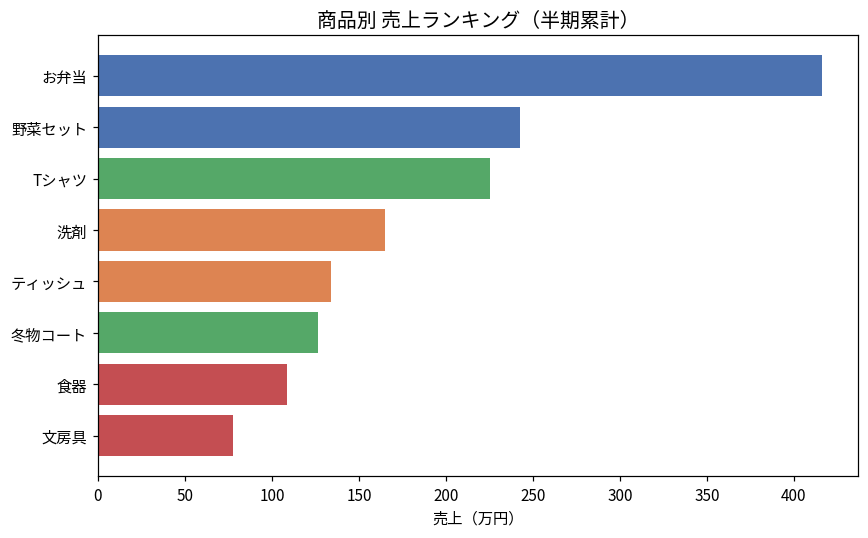

In [7]:

fig, ax = plt.subplots(figsize=(8, 5))
colors = product_rank["department"].map(
    {"食品": "#4C72B0", "日用品": "#DD8452", "衣料品": "#55A868", "雑貨": "#C44E52"}
)
ax.barh(product_rank["product"], product_rank["amount_man"], color=colors)
ax.invert_yaxis()
ax.set_title("商品別 売上ランキング（半期累計）", fontsize=13)
ax.set_xlabel("売上（万円）")
fig.tight_layout()
fig.savefig("../images/product_ranking.png")
plt.show()



**読み取れること**：単価・点数のバランスから「お弁当」が単一商品として最大の売上を作っている。
一方で「Tシャツ」はトレンド係数を強めに設定した通り、期間後半にかけて伸びが大きい
（次のセルで確認）。


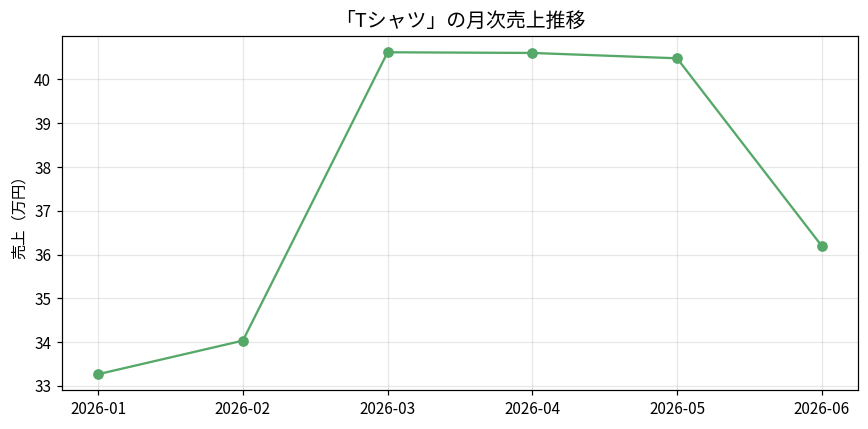

In [8]:

tshirt = product[product["product"] == "Tシャツ"].copy()
tshirt_monthly = tshirt.groupby("month")["amount"].sum() / 10000

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tshirt_monthly.index, tshirt_monthly.values, marker="o", color="#55A868")
ax.set_title("「Tシャツ」の月次売上推移", fontsize=13)
ax.set_ylabel("売上（万円）")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../images/tshirt_trend.png")
plt.show()



## 4. Excelレポートの自動生成（openpyxl）

ここまでの分析結果を、**そのままExcelファイルとして出力**します。
毎回同じ集計・グラフ作成を手作業で行っていた業務を想定し、
このスクリプトを実行するだけでレポートが完成する状態を目指しました。


In [9]:

def style_header(ws, row, n_cols):
    fill = PatternFill(start_color="4C72B0", end_color="4C72B0", fill_type="solid")
    font = Font(color="FFFFFF", bold=True)
    for col in range(1, n_cols + 1):
        cell = ws.cell(row=row, column=col)
        cell.fill = fill
        cell.font = font
        cell.alignment = Alignment(horizontal="center")


def write_df(ws, df, start_row=1, start_col=1):
    for r_idx, row in enumerate(dataframe_to_rows(df, index=False, header=True)):
        for c_idx, value in enumerate(row):
            ws.cell(row=start_row + r_idx, column=start_col + c_idx, value=value)
    style_header(ws, start_row, len(df.columns))
    return start_row + len(df) + 1  # 次に書き込める行


wb = Workbook()

# --- シート1: 部門別売上 ---
ws1 = wb.active
ws1.title = "部門別売上"
dept_monthly_report = dept_monthly.reset_index()
next_row = write_df(ws1, dept_monthly_report)

chart1 = LineChart()
chart1.title = "部門別 月次売上推移"
chart1.y_axis.title = "売上（円）"
chart1.x_axis.title = "月"
data_ref = Reference(ws1, min_col=2, max_col=dept_monthly_report.shape[1],
                      min_row=1, max_row=dept_monthly_report.shape[0] + 1)
cats_ref = Reference(ws1, min_col=1, min_row=2, max_row=dept_monthly_report.shape[0] + 1)
chart1.add_data(data_ref, titles_from_data=True)
chart1.set_categories(cats_ref)
ws1.add_chart(chart1, f"A{next_row + 1}")

# --- シート2: 商品別ランキング ---
ws2 = wb.create_sheet("商品別ランキング")
next_row2 = write_df(ws2, product_rank[["product", "department", "amount"]])

chart2 = BarChart()
chart2.type = "bar"
chart2.title = "商品別 売上ランキング"
chart2.y_axis.title = "売上（円）"
data_ref2 = Reference(ws2, min_col=3, min_row=1, max_row=product_rank.shape[0] + 1)
cats_ref2 = Reference(ws2, min_col=1, min_row=2, max_row=product_rank.shape[0] + 1)
chart2.add_data(data_ref2, titles_from_data=True)
chart2.set_categories(cats_ref2)
ws2.add_chart(chart2, f"A{next_row2 + 1}")

# --- シート3: サマリー ---
ws3 = wb.create_sheet("サマリー", 0)
ws3["A1"] = "売上分析レポート（自動生成）"
ws3["A1"].font = Font(bold=True, size=14)
ws3["A3"] = "対象期間"
ws3["B3"] = f"{dept['date'].min().date()} 〜 {dept['date'].max().date()}"
ws3["A4"] = "総売上（円）"
ws3["B4"] = int(dept["amount"].sum())
ws3["A5"] = "最も売上の大きい部門"
ws3["B5"] = dept_total.idxmax()
ws3["A6"] = "最も売上の大きい商品"
ws3["B6"] = product_rank.iloc[0]["product"]
for row in range(3, 7):
    ws3.cell(row=row, column=1).font = Font(bold=True)

wb.save("../output/sales_report.xlsx")
print("output/sales_report.xlsx を出力しました")


output/sales_report.xlsx を出力しました



## 5. 分析まとめ

- 食品部門が安定して最大の売上規模を持ち、店舗全体の収益の土台になっている。
- 衣料品は季節変動が大きく、冬場（1月・12月）に売上が伸びる。仕入れ・在庫計画は
  季節を見越して立てる必要がある。
- 商品単位では「Tシャツ」が期間後半にかけて伸びており、部門全体のトレンドとは別に
  商品単位でも動きを追う価値があることが分かった。
- Excelレポートの自動生成により、毎回手作業で行っていた「集計→グラフ作成→ファイル保存」
  の一連の流れを1回のスクリプト実行に置き換えられた。

## 今後やりたいこと

- 実データでの再検証
- レポート生成をFastAPIでAPI化し、CSVをアップロードすると自動でExcelレポートが
  ダウンロードできる仕組みを作る
- 前月比・前年同月比などの比較指標を追加する

## 学びメモ（lessons learned）

- `pivot_table` で部門別×月別のクロス集計を行う際、列の並び順が自動的にアルファベット順や
  出現順になってしまう点に気づき、明示的に列順を指定する必要があった。
- `openpyxl` でExcelにグラフを埋め込む際、`Reference`で参照するセル範囲とデータ実体の
  行番号がずれるとグラフが正しく描画されない点でつまずいた。ヘッダー行を含めるかどうかを
  `titles_from_data`で制御する必要があることを理解した。
- 分析（pandas/matplotlib）とレポート自動化（openpyxl）を1つのプロジェクトとして
  つなげたことで、「分析して終わり」ではなく「日々の業務に落とし込む」までの流れを
  意識してコードを書く経験になった。
